In [2]:
%pip install missingno

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

# Display all columns
pd.set_option("display.max_columns", None)

# Display wider tables
pd.set_option("display.width", 150)

# Display more rows
pd.set_option("display.max_rows", 100)

In [9]:
df = pd.read_csv("C:/Users/Admin/Desktop/Fifa prediction/Raw/results.csv")

In [10]:
print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

DATASET SHAPE
(49494, 9)


In [11]:
print("="*60)
print("FIRST 5 ROWS")
print("="*60)
df.head()

FIRST 5 ROWS


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [12]:
print("="*60)
print("LAST 5 ROWS")
print("="*60)
df.tail()

LAST 5 ROWS


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49489,2026-07-02,Switzerland,Algeria,NaN,NaN,FIFA World Cup,Vancouver,Canada,True
49490,2026-07-03,Australia,Egypt,NaN,NaN,FIFA World Cup,Arlington,United States,True
49491,2026-07-03,Argentina,Cape Verde,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49492,2026-07-03,Colombia,Ghana,NaN,NaN,FIFA World Cup,Kansas City,United States,True
49493,2026-07-04,Canada,Morocco,NaN,NaN,FIFA World Cup,Houston,United States,True


In [13]:
print("="*60)
print("COLUMN NAMES")
print("="*60)

print(df.columns.tolist())

COLUMN NAMES
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']


In [14]:
print("="*60)
print("DATA TYPES")
print("="*60)

df.info()

DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49494 entries, 0 to 49493
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49494 non-null  object 
 1   home_team   49494 non-null  object 
 2   away_team   49494 non-null  object 
 3   home_score  49481 non-null  float64
 4   away_score  49481 non-null  float64
 5   tournament  49494 non-null  object 
 6   city        49494 non-null  object 
 7   country     49494 non-null  object 
 8   neutral     49494 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [15]:
print("="*60)
print("MISSING VALUES")
print("="*60)

missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

MISSING VALUES
home_score    13
away_score    13
dtype: int64


In [16]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent = missing_percent[missing_percent>0]

print(missing_percent.sort_values(ascending=False))

home_score    0.026266
away_score    0.026266
dtype: float64


In [17]:
print("="*60)
print("DUPLICATES")
print("="*60)

print(df.duplicated().sum())

DUPLICATES
0


In [18]:
df.describe()

,home_score,away_score
count,49481.000000,49481.000000
mean,1.757260,1.181908
std,1.774046,1.401737
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [19]:
for col in df.columns:
    print("-"*40)
    print(col)
    print(df[col].nunique())

----------------------------------------
date
16478
----------------------------------------
home_team
327
----------------------------------------
away_team
321
----------------------------------------
home_score
26
----------------------------------------
away_score
22
----------------------------------------
tournament
200
----------------------------------------
city
2089
----------------------------------------
country
269
----------------------------------------
neutral
2


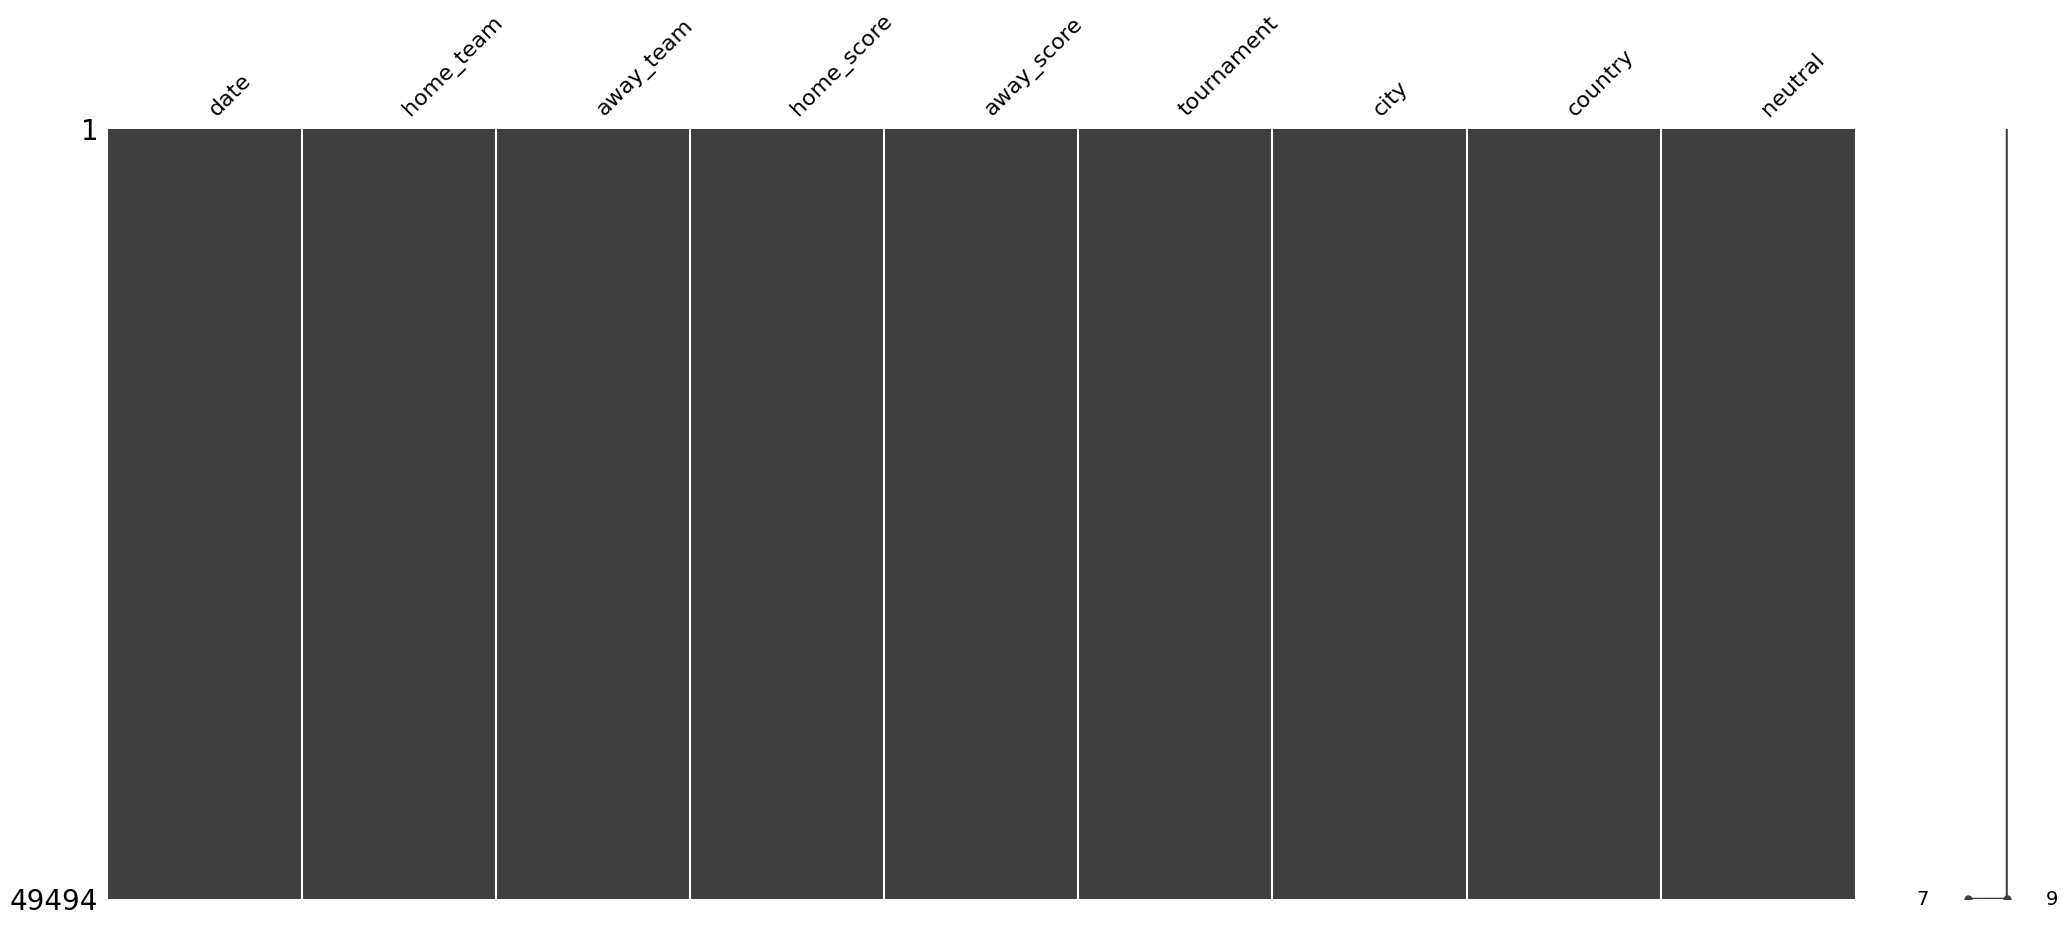

In [20]:
msno.matrix(df)

plt.show()

In [21]:
df['tournament'].value_counts()

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1053
                                        ...  
Copa Confraternidad                         1
ConIFA Challenger Cup                       1
Benedikt Fontana Cup                        1
CONIFA World Cup qualification              1
South Asian Super Cup                       1
Name: count, Length: 200, dtype: int64

In [22]:
df['date'] = pd.to_datetime(df['date'])

In [23]:
num_cols = df.select_dtypes(include=np.number).columns

print(num_cols)

Index(['home_score', 'away_score'], dtype='object')


In [24]:
cat_cols = df.select_dtypes(include='object').columns

print(cat_cols)

Index(['home_team', 'away_team', 'tournament', 'city', 'country'], dtype='object')


In [ ]:
def dataset_report(df):
    print("="*60)
    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicates:")
    print(df.duplicated().sum())

    print("\nSummary:")
    display(df.describe(include='all'))

    summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

def dataset_report(df):
    print("="*60)
    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicates:")
    print(df.duplicated().sum())

    print("\nSummary:")
    display(df.describe(include='all'))

    summary = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.values,
        "Missing Values": df.isnull().sum().values,
        "Unique Values": df.nunique().values
    })

    display(summary)
    return summary

In [38]:
dataset_report(df)

Shape: (49494, 9)

Columns:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

Data Types:
date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

Missing Values:
date           0
home_team      0
away_team      0
home_score    13
away_score    13
tournament     0
city           0
country        0
neutral        0
dtype: int64

Duplicates:
0

Summary:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
count,49494,49494,49494,49481.000000,49481.000000,49494,49494,49494,49494
unique,NaN,327,321,NaN,NaN,200,2089,269,2
top,NaN,Brazil,Uruguay,NaN,NaN,Friendly,Kuala Lumpur,United States,False
freq,NaN,617,585,NaN,NaN,18388,745,1572,36358
mean,1994-05-26 14:18:27.625166592,NaN,NaN,1.757260,1.181908,NaN,NaN,NaN,NaN
min,1872-11-30 00:00:00,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,1980-09-10 00:00:00,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN
50%,2000-07-16 00:00:00,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN
75%,2013-07-18 00:00:00,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN
max,2026-07-04 00:00:00,NaN,NaN,31.000000,21.000000,NaN,NaN,NaN,NaN


In [39]:
corr = df.corr(numeric_only=True)

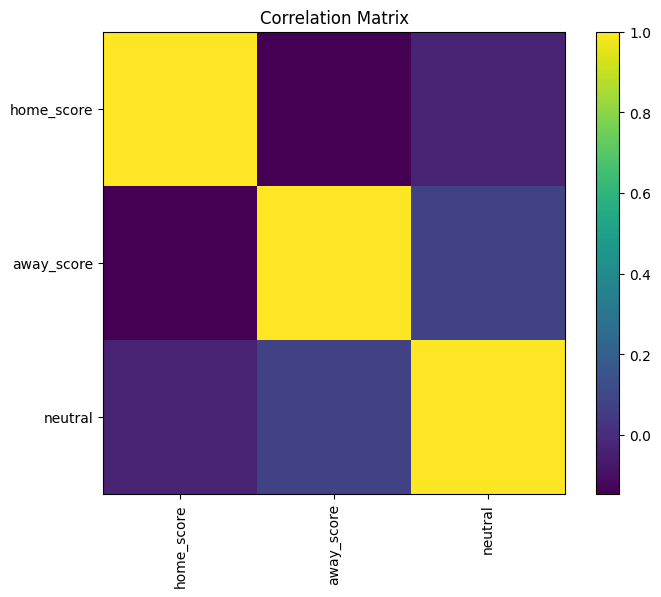

In [36]:
plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()